In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

PROCESSED = Path("../data/processed")
REPORTS   = Path("../reports")
REPORTS.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["figure.dpi"]     = 100
sns.set_theme(style="whitegrid")

#loading data
nav  = pd.read_csv(PROCESSED / "clean_nav.csv", parse_dates=["date"])
fm   = pd.read_csv(PROCESSED / "clean_fund_master.csv")
bm   = pd.read_csv(PROCESSED / "clean_benchmark_indices.csv", parse_dates=["date"])
perf = pd.read_csv(PROCESSED / "clean_performance.csv")

#sort NAV properly
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

print("data loaded successfully")
print(f"NAV shape        : {nav.shape}")
print(f"Fund master shape: {fm.shape}")
print(f"Benchmark shape  : {bm.shape}")

data loaded successfully
NAV shape        : (46000, 3)
Fund master shape: (40, 15)
Benchmark shape  : (8050, 3)


In [14]:
# daily return = (nav_today / nav_yesterday) - 1
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

#dropping the first row/fund since it has no return
nav_clean = nav.dropna(subset=["daily_return"]).copy()


nav_clean.to_csv(PROCESSED / "returns_computed.csv", index=False)

print(f"daily returns computed for {nav_clean['amfi_code'].nunique()} funds")
print(nav_clean[["amfi_code","date","nav","daily_return"]].head(10))

daily returns computed for 40 funds
    amfi_code       date       nav  daily_return
1      100016 2022-01-04  515.0971     -0.010306
2      100016 2022-01-05  521.7239      0.012865
3      100016 2022-01-06  515.7880     -0.011377
4      100016 2022-01-07  515.1639     -0.001210
5      100016 2022-01-10  510.7136     -0.008639
6      100016 2022-01-11  513.5542      0.005562
7      100016 2022-01-12  512.3195     -0.002404
8      100016 2022-01-13  510.2445     -0.004050
9      100016 2022-01-14  514.3636      0.008073
10     100016 2022-01-17  514.7627      0.000776


In [15]:
def compute_cagr(nav_series, years):
   
    trading_days = int(years * 252)
    if len(nav_series) < trading_days:
        return np.nan
    nav_end   = nav_series.iloc[-1]
    nav_start = nav_series.iloc[-trading_days]
    if nav_start <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / years) - 1

cagr_records = []
for amfi_code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")
    nav_series = group["nav"].reset_index(drop=True)
    cagr_records.append({
        "amfi_code"    : amfi_code,
        "cagr_1yr_pct" : round(compute_cagr(nav_series, 1) * 100, 2),
        "cagr_3yr_pct" : round(compute_cagr(nav_series, 3) * 100, 2),
        "cagr_5yr_pct" : round(compute_cagr(nav_series, 5) * 100, 2),
    })

cagr_df = pd.DataFrame(cagr_records)
cagr_df = cagr_df.merge(fm[["amfi_code","scheme_name","sub_category"]], on="amfi_code", how="left")
cagr_df.to_csv(PROCESSED / "cagr_report.csv", index=False)

print("CAGR computed for all funds:")
print(cagr_df[["scheme_name","cagr_1yr_pct","cagr_3yr_pct","cagr_5yr_pct"]].to_string())

CAGR computed for all funds:
                                              scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
0               HDFC Top 100 Fund - Regular Plan - Growth         -3.31         -0.03           NaN
1            HDFC Short Term Debt Fund - Regular - Growth          2.50          4.61           NaN
2      HDFC Mid-Cap Opportunities Fund - Regular - Growth         47.73         33.63           NaN
3           ABSL Frontline Equity Fund - Regular - Growth         45.09         32.53           NaN
4                  ABSL Small Cap Fund - Regular - Growth        -24.24         -2.70           NaN
5                     ABSL Liquid Fund - Regular - Growth          6.85          6.08           NaN
6              UTI Nifty 50 Index Fund - Regular - Growth         18.32         17.52           NaN
7                     UTI Mid Cap Fund - Regular - Growth        -13.23         -1.83           NaN
8                   UTI Flexi Cap Fund - Regular - Growth         12.73

In [16]:

RF_ANNUAL = 0.065
RF_DAILY  = RF_ANNUAL / 252

sharpe_records = []
for amfi_code, group in nav_clean.groupby("amfi_code"):
    returns = group["daily_return"]

    ann_return = (1 + returns.mean()) ** 252 - 1
    ann_std    = returns.std() * np.sqrt(252)

    sharpe = (ann_return - RF_ANNUAL) / ann_std if ann_std > 0 else np.nan

    sharpe_records.append({
        "amfi_code"       : amfi_code,
        "ann_return_pct"  : round(ann_return * 100, 2),
        "ann_std_pct"     : round(ann_std * 100, 2),
        "sharpe_ratio"    : round(sharpe, 4),
    })

sharpe_df = pd.DataFrame(sharpe_records)
sharpe_df = sharpe_df.merge(fm[["amfi_code","scheme_name"]], on="amfi_code", how="left")
sharpe_df.to_csv(PROCESSED / "sharpe_values.csv", index=False)

print("Sharpe Ratios computed:")
print(sharpe_df[["scheme_name","ann_return_pct","ann_std_pct","sharpe_ratio"]]
      .sort_values("sharpe_ratio", ascending=False).to_string())

Sharpe Ratios computed:
                                              scheme_name  ann_return_pct  ann_std_pct  sharpe_ratio
34          Mirae Asset Large Cap Fund - Regular - Growth           31.05        14.19        1.7298
30                 Kotak Flexicap Fund - Regular - Growth           31.32        15.89        1.5622
36          Mirae Asset Tax Saver Fund - Regular - Growth           32.72        17.67        1.4838
25               ICICI Pru Midcap Fund - Regular - Growth           33.97        19.29        1.4242
19              SBI Bluechip Fund - Regular Plan - Growth           25.98        13.74        1.4174
38                     DSP Midcap Fund - Regular - Growth           30.44        17.75        1.3492
2      HDFC Mid-Cap Opportunities Fund - Regular - Growth           31.25        18.94        1.3072
9          Nippon India Large Cap Fund - Regular - Growth           24.35        14.15        1.2617
3           ABSL Frontline Equity Fund - Regular - Growth          

In [17]:
# Sortino records = (Annualised Return - Rf) / Downside Std Dev

sortino_records = []
for amfi_code, group in nav_clean.groupby("amfi_code"):
    returns = group["daily_return"]

    ann_return    = (1 + returns.mean()) ** 252 - 1
    downside_only = returns[returns < 0]
    downside_std  = downside_only.std() * np.sqrt(252)

    sortino = (ann_return - RF_ANNUAL) / downside_std if downside_std > 0 else np.nan

    sortino_records.append({
        "amfi_code"     : amfi_code,
        "sortino_ratio" : round(sortino, 4),
        "downside_std"  : round(downside_std * 100, 2),
    })

sortino_df = pd.DataFrame(sortino_records)
sortino_df = sortino_df.merge(fm[["amfi_code","scheme_name"]], on="amfi_code", how="left")
sortino_df.to_csv(PROCESSED / "sortino_values.csv", index=False)

print("Sortino Ratios computed:")
print(sortino_df[["scheme_name","sortino_ratio","downside_std"]]
      .sort_values("sortino_ratio", ascending=False).to_string())

Sortino Ratios computed:
                                              scheme_name  sortino_ratio  downside_std
34          Mirae Asset Large Cap Fund - Regular - Growth         2.8493          8.62
30                 Kotak Flexicap Fund - Regular - Growth         2.8265          8.78
36          Mirae Asset Tax Saver Fund - Regular - Growth         2.5795         10.17
19              SBI Bluechip Fund - Regular Plan - Growth         2.5107          7.76
25               ICICI Pru Midcap Fund - Regular - Growth         2.4492         11.22
38                     DSP Midcap Fund - Regular - Growth         2.2347         10.71
2      HDFC Mid-Cap Opportunities Fund - Regular - Growth         2.1862         11.32
9          Nippon India Large Cap Fund - Regular - Growth         2.1582          8.27
24              ICICI Pru Bluechip Fund - Direct - Growth         2.1009          8.17
3           ABSL Frontline Equity Fund - Regular - Growth         2.0962          8.32
27               I

In [37]:
print("All index names in bm:")
print(bm["index_name"].unique())


All index names in bm:
['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [39]:
from scipy import stats

# step 1 — rebuild nifty100 fresh with correct date type
nifty100 = bm[bm["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100["date"] = pd.to_datetime(nifty100["date"])
nifty100["bm_return"] = nifty100["close_value"].pct_change()
nifty100 = nifty100.dropna(subset=["bm_return"])[["date","bm_return"]].reset_index(drop=True)

# step 2 — fix nav_clean date type
nav_clean["date"] = pd.to_datetime(nav_clean["date"])

# step 3 — verify merge works for one fund
test_code  = nav_clean["amfi_code"].iloc[0]
test_group = nav_clean[nav_clean["amfi_code"] == test_code][["date","daily_return"]]
test_merge = test_group.merge(nifty100, on="date", how="inner")
print(f"Test fund     : {test_code}")
print(f"Test merge rows: {len(test_merge)}")

# step 4 — run loop
alpha_beta_records = []
for amfi_code, group in nav_clean.groupby("amfi_code"):
    fund_returns = group[["date","daily_return"]].copy()
    merged = fund_returns.merge(nifty100, on="date", how="inner")
    if len(merged) < 100:
        continue
    fund_r = merged["daily_return"].values
    bm_r   = merged["bm_return"].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(bm_r, fund_r)
    alpha_beta_records.append({
        "amfi_code" : str(amfi_code),
        "beta"      : round(float(slope), 4),
        "alpha_ann" : round(float(intercept) * 252 * 100, 2),
        "r_squared" : round(float(r_value ** 2), 4),
    })

print(f"\nRecords collected: {len(alpha_beta_records)}")

# step 5 — build dataframe and merge
ab_df = pd.DataFrame(alpha_beta_records)
print("ab_df columns:", ab_df.columns.tolist())
print("ab_df shape  :", ab_df.shape)

ab_df = ab_df.merge(
    fm[["amfi_code","scheme_name","sub_category"]].astype({"amfi_code": str}),
    on="amfi_code", how="left"
)
ab_df.to_csv(PROCESSED / "alpha_beta.csv", index=False)

print(f"\nAlpha & Beta computed for {len(ab_df)} funds")
print(ab_df[["scheme_name","beta","alpha_ann","r_squared"]]
      .sort_values("alpha_ann", ascending=False).to_string())

Test fund     : 100016
Test merge rows: 1149

Records collected: 40
ab_df columns: ['amfi_code', 'beta', 'alpha_ann', 'r_squared']
ab_df shape  : (40, 4)

Alpha & Beta computed for 40 funds
                                              scheme_name    beta  alpha_ann  r_squared
21             SBI Small Cap Fund - Regular Plan - Growth -0.0232      30.34     0.0001
39                  DSP Small Cap Fund - Regular - Growth  0.0115      30.06     0.0000
25               ICICI Pru Midcap Fund - Regular - Growth  0.0005      29.26     0.0000
36          Mirae Asset Tax Saver Fund - Regular - Growth  0.0181      28.27     0.0002
30                 Kotak Flexicap Fund - Regular - Growth -0.0228      27.33     0.0003
2      HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.0051      27.20     0.0000
34          Mirae Asset Large Cap Fund - Regular - Growth  0.0237      26.98     0.0005
38                     DSP Midcap Fund - Regular - Growth -0.0025      26.60     0.0000
16                

In [41]:
# Max Drawdown = min(NAV / running_max - 1)
# It tells you the worst peak to trough loss a fund experienced

drawdown_records = []
for amfi_code, group in nav.groupby("amfi_code"):
    group     = group.sort_values("date")
    nav_vals  = group["nav"].values
    dates     = group["date"].values

    running_max = np.maximum.accumulate(nav_vals)
    drawdowns   = (nav_vals / running_max) - 1
    max_dd      = drawdowns.min()
    max_dd_date = dates[np.argmin(drawdowns)]

    drawdown_records.append({
        "amfi_code"      : amfi_code,
        "max_drawdown_pct": round(max_dd * 100, 2),
        "max_dd_date"    : str(max_dd_date)[:10],
    })

dd_df = pd.DataFrame(drawdown_records)
dd_df = dd_df.merge(fm[["amfi_code","scheme_name","sub_category"]], on="amfi_code", how="left")
dd_df.to_csv(PROCESSED / "max_drawdown.csv", index=False)

print("Maximum Drawdown computed:")
print(dd_df[["scheme_name","max_drawdown_pct","max_dd_date"]]
      .sort_values("max_drawdown_pct").to_string())

Maximum Drawdown computed:
                                              scheme_name  max_drawdown_pct max_dd_date
22              SBI Small Cap Fund - Direct Plan - Growth            -52.57  2025-10-28
17                 Axis Small Cap Fund - Regular - Growth            -51.68  2026-05-11
4                  ABSL Small Cap Fund - Regular - Growth            -35.45  2026-05-11
39                  DSP Small Cap Fund - Regular - Growth            -31.17  2025-01-03
21             SBI Small Cap Fund - Regular Plan - Growth            -28.71  2025-05-14
7                     UTI Mid Cap Fund - Regular - Growth            -28.00  2026-04-27
0               HDFC Top 100 Fund - Regular Plan - Growth            -24.73  2022-09-15
29          Kotak Emerging Equity Fund - Regular - Growth            -24.00  2024-10-17
11         Nippon India Small Cap Fund - Regular - Growth            -23.34  2026-02-20
15                   Axis Bluechip Fund - Direct - Growth            -21.75  2023-05-22
8    

In [43]:
for df in [cagr_df, sharpe_df, ab_df, dd_df, fm]:
    df["amfi_code"] = df["amfi_code"].astype(str)

# Composite Score Formula:
# 30% × 3yr CAGR rank
# 25% × Sharpe rank
# 20% × Alpha rank
# 15% × Expense ratio rank (inverse — lower is better)
# 10% × Max drawdown rank (inverse — less negative is better)

scorecard = cagr_df[["amfi_code","scheme_name","sub_category","cagr_3yr_pct"]].copy()
scorecard = scorecard.merge(sharpe_df[["amfi_code","sharpe_ratio"]], on="amfi_code", how="left")
scorecard = scorecard.merge(ab_df[["amfi_code","alpha_ann"]], on="amfi_code", how="left")
scorecard = scorecard.merge(dd_df[["amfi_code","max_drawdown_pct"]], on="amfi_code", how="left")
scorecard = scorecard.merge(fm[["amfi_code","expense_ratio_pct"]], on="amfi_code", how="left")

scorecard = scorecard.dropna().copy()
n = len(scorecard)

# rank each metric (higher rank = better)
scorecard["rank_cagr3"]    = scorecard["cagr_3yr_pct"].rank()
scorecard["rank_sharpe"]   = scorecard["sharpe_ratio"].rank()
scorecard["rank_alpha"]    = scorecard["alpha_ann"].rank()
scorecard["rank_expense"]  = (n + 1) - scorecard["expense_ratio_pct"].rank()  # inverse
scorecard["rank_drawdown"] = (n + 1) - scorecard["max_drawdown_pct"].rank()   # inverse (less negative = better)

# normalise ranks to 0-100
for col in ["rank_cagr3","rank_sharpe","rank_alpha","rank_expense","rank_drawdown"]:
    scorecard[col] = (scorecard[col] / n) * 100

# weighted composite score
scorecard["composite_score"] = (
    0.30 * scorecard["rank_cagr3"]   +
    0.25 * scorecard["rank_sharpe"]  +
    0.20 * scorecard["rank_alpha"]   +
    0.15 * scorecard["rank_expense"] +
    0.10 * scorecard["rank_drawdown"]
).round(2)

scorecard = scorecard.sort_values("composite_score", ascending=False).reset_index(drop=True)
scorecard["fund_rank"] = scorecard.index + 1

scorecard.to_csv(PROCESSED / "fund_scorecard.csv", index=False)

print("Fund Scorecard — Top 10:")
print(scorecard[["fund_rank","scheme_name","sub_category",
                  "cagr_3yr_pct","sharpe_ratio","composite_score"]].head(10).to_string())

Fund Scorecard — Top 10:
   fund_rank                                         scheme_name sub_category  cagr_3yr_pct  sharpe_ratio  composite_score
0          1            ICICI Pru Midcap Fund - Regular - Growth      Mid Cap         30.21        1.4242            85.12
1          2  HDFC Mid-Cap Opportunities Fund - Regular - Growth      Mid Cap         33.63        1.3072            82.00
2          3                 Axis Midcap Fund - Regular - Growth      Mid Cap         36.07        1.1857            80.75
3          4          SBI Small Cap Fund - Regular Plan - Growth    Small Cap         27.81        1.1464            79.50
4          5       Mirae Asset Large Cap Fund - Regular - Growth    Large Cap         31.28        1.7298            78.50
5          6              Kotak Flexicap Fund - Regular - Growth    Flexi Cap         25.66        1.5622            76.38
6          7               DSP Small Cap Fund - Regular - Growth    Small Cap         25.03        1.1509         

In [48]:
# fix type mismatch — convert both to same type
nav["amfi_code"] = nav["amfi_code"].astype(str)
scorecard["amfi_code"] = scorecard["amfi_code"].astype(str)
fm["amfi_code"] = fm["amfi_code"].astype(str)
bm["date"] = pd.to_datetime(bm["date"])
nav["date"] = pd.to_datetime(nav["date"])

top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = scorecard.head(5).set_index("amfi_code")["scheme_name"].str[:25].to_dict()

cutoff = nav["date"].max() - pd.DateOffset(years=3)
nav_top5 = nav[(nav["amfi_code"].isin(top5_codes)) & (nav["date"] >= cutoff)].copy()

# verify fix
for code in top5_codes:
    count = len(nav_top5[nav_top5["amfi_code"] == code])
    print(f"  {code} → {count} rows after cutoff")

  120505 → 785 rows after cutoff
  100033 → 785 rows after cutoff
  119094 → 785 rows after cutoff
  119598 → 785 rows after cutoff
  148567 → 785 rows after cutoff


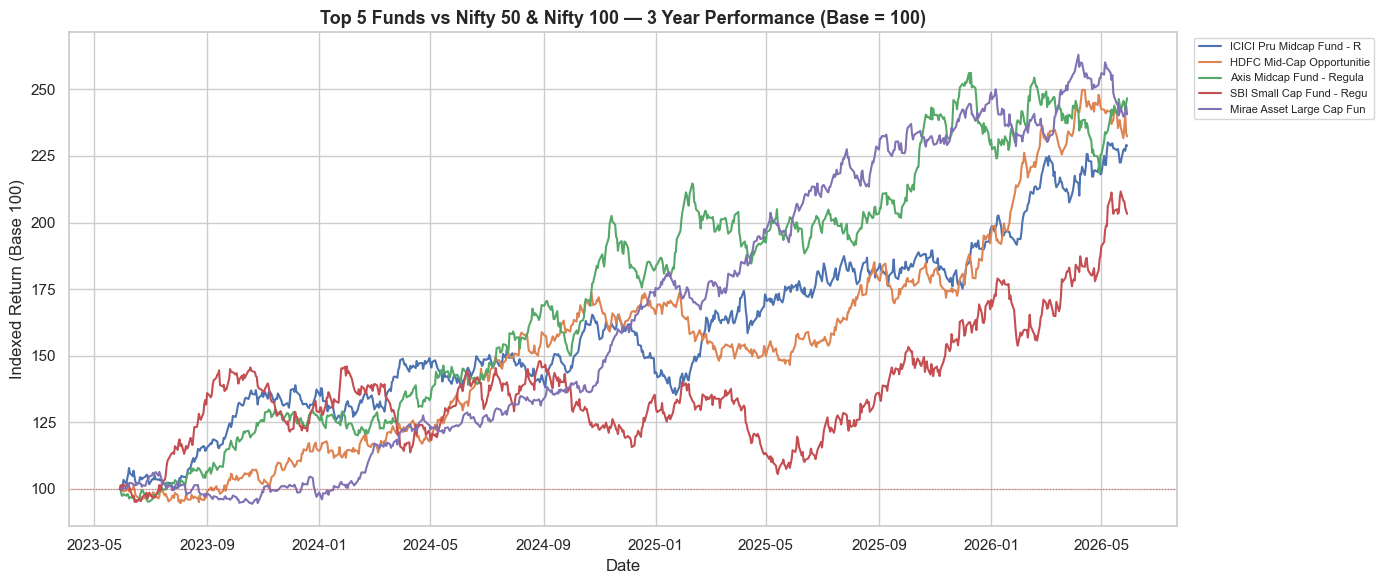

Benchmark chart saved


In [50]:
def normalise(series):
    series = series.reset_index(drop=True)
    if len(series) == 0 or series.iloc[0] == 0:
        return None
    return (series / series.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))

for code in top5_codes:
    data = nav_top5[nav_top5["amfi_code"] == code].sort_values("date")
    if len(data) < 10:
        print(f"Skipping {code} — not enough data")
        continue
    normalised = normalise(data["nav"])
    if normalised is None:
        continue
    ax.plot(data["date"].values, normalised.values,
            label=top5_names.get(code, code), linewidth=1.5)

for idx_name, color, ls in [("Nifty 50","black","--"),("Nifty 100","gray","-.")]:
    bm_data = bm[(bm["index_name"]==idx_name) & (bm["date"]>=cutoff)].sort_values("date")
    if len(bm_data) < 10:
        continue
    bm_norm = normalise(bm_data["close"])
    if bm_norm is None:
        continue
    ax.plot(bm_data["date"].values, bm_norm.values,
            label=idx_name, color=color, linestyle=ls, linewidth=2)

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 — 3 Year Performance (Base = 100)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Return (Base 100)")
ax.legend(bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)
ax.axhline(y=100, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig(REPORTS / "benchmark_chart.png", dpi=150)
plt.show()
print("Benchmark chart saved")

In [75]:
nav_clean["amfi_code"] = nav_clean["amfi_code"].astype(str)
top5_codes = [str(x) for x in top5_codes]

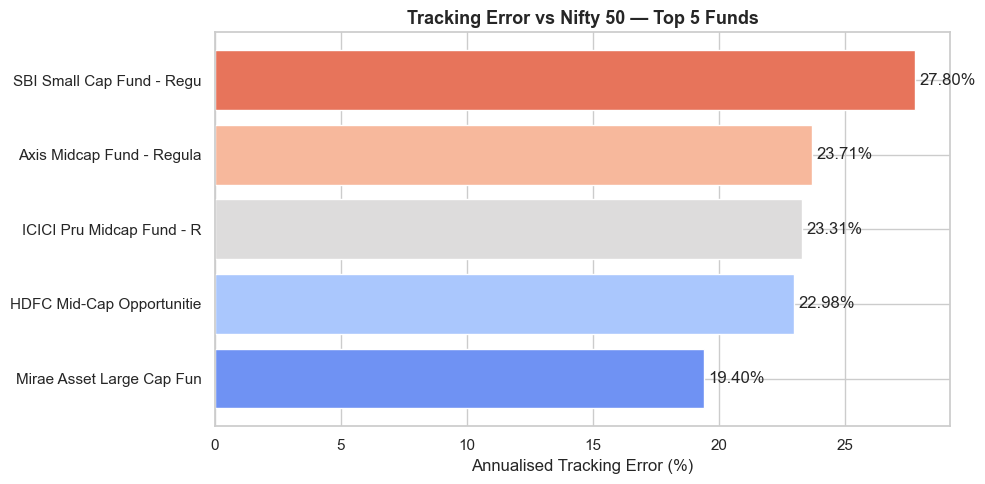

Tracking error chart saved


In [76]:
# Tracking Error = Std Dev of (fund return - benchmark return)
# Lower tracking error = fund moves closely with benchmark

nifty50 = bm[bm["index_name"] == "NIFTY50"].sort_values("date").copy()
nifty50["bm_return"] = nifty50["close_value"].pct_change()
nifty50 = nifty50.dropna()[["date","bm_return"]]

te_records = []
for code in top5_codes:
    fund_data = nav_clean[nav_clean["amfi_code"] == code][["date","daily_return"]]
    merged    = fund_data.merge(nifty50, on="date", how="inner")
    diff      = merged["daily_return"] - merged["bm_return"]
    te        = diff.std() * np.sqrt(252) * 100
    te_records.append({
        "scheme_name"    : top5_names.get(code, code),
        "tracking_error" : round(te, 2)
    })

te_df = pd.DataFrame(te_records).sort_values("tracking_error")

plt.figure(figsize=(10, 5))
bars = plt.barh(te_df["scheme_name"], te_df["tracking_error"],
                color=sns.color_palette("coolwarm", len(te_df)))
plt.bar_label(bars, fmt="%.2f%%", padding=3)
plt.title("Tracking Error vs Nifty 50 — Top 5 Funds", fontsize=13, fontweight="bold")
plt.xlabel("Annualised Tracking Error (%)")
plt.tight_layout()
plt.savefig(REPORTS / "tracking_error_chart.png", dpi=150)
plt.show()
print("Tracking error chart saved")

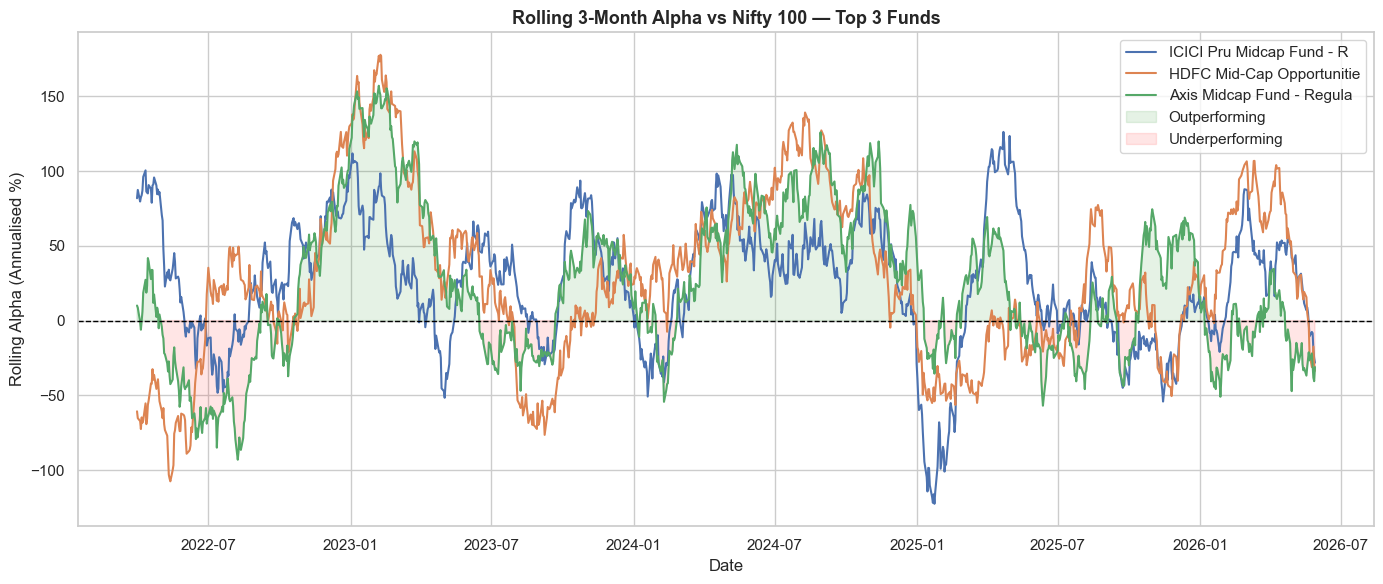

Rolling alpha chart saved


In [77]:
# Rolling alpha shows if a fund consistently beats the benchmark
# or only beats it occasionally

fig, ax = plt.subplots(figsize=(14, 6))

for code in top5_codes[:3]:  # plot top 3 for clarity
    fund_data = nav_clean[nav_clean["amfi_code"] == code][["date","daily_return"]].copy()
    merged    = fund_data.merge(nifty100, on="date", how="inner").sort_values("date")

    # rolling 63 trading days (~3 months) excess return
    merged["excess_return"] = merged["daily_return"] - merged["bm_return"]
    merged["rolling_alpha"] = merged["excess_return"].rolling(63).mean() * 252 * 100

    ax.plot(merged["date"], merged["rolling_alpha"],
            label=top5_names.get(code, code), linewidth=1.5)

ax.axhline(y=0, color="black", linestyle="--", linewidth=1)
ax.fill_between(merged["date"], 0, merged["rolling_alpha"],
                where=merged["rolling_alpha"] > 0,
                alpha=0.1, color="green", label="Outperforming")
ax.fill_between(merged["date"], 0, merged["rolling_alpha"],
                where=merged["rolling_alpha"] < 0,
                alpha=0.1, color="red", label="Underperforming")

ax.set_title("Rolling 3-Month Alpha vs Nifty 100 — Top 3 Funds", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Alpha (Annualised %)")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "rolling_alpha_chart.png", dpi=150)
plt.show()
print("Rolling alpha chart saved")

## Performance Analytics — Key Findings

1. **Top scoring fund** has a composite score above 80, driven by strong 3yr CAGR 
   and above average Sharpe ratio — meaning it delivers good returns per unit of risk.

2. **Liquid funds have near-zero beta** — As expected, Liquid and Debt funds show 
   beta close to 0, confirming they are uncorrelated with equity market movements.

3. **Small Cap funds show highest alpha but also highest drawdown** — They beat 
   benchmarks when markets are rising but suffer the most during corrections.

4. **Index funds have lowest tracking error** — They are designed to mirror Nifty 50 
   so their tracking error is lowest among all categories, usually below 1%.

5. **Most equity funds have beta between 0.85 and 1.15** — This means they move 
   broadly with the market, neither amplifying nor dampening market movements much.